# Semantic Boundary Splitting — Cut Where Meaning Changes

## What problem does this solve?

Fixed-window chunking cuts every N tokens, regardless of topic. A 384-token window that lands mid-paragraph snaps the idea in half; the chunk on one side has the premise, the chunk on the other has the conclusion. Neither chunk on its own answers the question, and both retrieve poorly because their vectors mix two topics.
Semantic boundary splitting walks adjacent sentence embeddings, watches the cosine distance, and cuts at the peaks. Chunks land on topic boundaries. The same paragraph stays in one chunk; the next paragraph starts the next chunk. The resulting chunks each represent one coherent idea, and the embeddings reflect that.

## Where it came from

Semantic chunking was popularised by Greg Kamradt in his 2023 Five Levels of Text Splitting tutorial. The idea — embed sentences, walk the diffs, cut at high-distance points — was implemented in LangChain's `SemanticChunker` (Dec 2023) and LlamaIndex's `SemanticSplitterNodeParser` (Jan 2024). The technique has stayed essentially unchanged since because the core algorithm is simple and the embedder does the hard work.
By 2026 every serious RAG framework ships a semantic chunker. The cookbook's `cookbook.chunkers.semantic_split` uses a percentile-based breakpoint threshold (default p90), which is the standard parameterisation.

## Where it fits in the RAG landscape

Four chunking strategies you should know:

- **Fixed window (Recipe 2 baseline).** Simplest. Cuts every N tokens.
- **Sentence-window (Recipe 9 building block).** Group N sentences, slide one.
- **Semantic boundary (this recipe).** Cut where embeddings disagree.
- **Propositional (Recipe 8).** LLM rewrites text into atomic factual claims.

Strategies stack: semantic boundary for the initial cut, then propositional within each semantic chunk for retrieval-level granularity. The cookbook's chunkers are designed to compose this way.

## When to use it (and when not to)

Use semantic boundary splitting for prose with clear topic transitions: Wikipedia articles, blog posts, textbooks. The technique earns its keep when paragraphs are visibly distinct ideas and the corpus is big enough that fixed-window chunks would routinely split paragraphs in half.
Skip it for technical documents with consistent structure: API references, structured datasets, tabular reports. Fixed-window is fine there because every chunk is roughly the same shape and the boundaries are determined by the document's existing markup.
Skip it for very short documents (under 1000 tokens). The overhead of embedding sentences is wasted; just use one chunk per document. Skip it also for code corpora — code's structure does not look like prose to the embedder, and the diff curve is noisy.

## The intuition

Three intuitions:

**The diff is a topic signal.** When two adjacent sentences talk about the same thing, their embeddings are similar. When they switch topics, the embeddings disagree. The size of the disagreement is a measurable topic boundary signal — concrete enough to threshold on.

**Percentile threshold is robust.** A hard cosine threshold (e.g. "cut at 0.7") fails on different corpora because diff magnitudes vary widely by domain. A percentile (e.g. "cut at the top 10 percent of diffs") adapts to the corpus's natural variation and ports between domains.

**Semantic chunks are usually longer than fixed-window.** A topic that runs three paragraphs gets one semantic chunk and three fixed chunks. The semantic chunk reads more coherently; the fixed chunks fragment the discussion. Embeddings of the semantic chunk represent one idea cleanly, where the fixed chunks each represent partial ideas with imported neighbouring context.

## Architecture

```mermaid
flowchart LR
  D[Document] --> S[Sentence split]
  S --> E[Embed each sentence]
  E --> DI[Per-pair cosine<br/>distance]
  DI --> P[Threshold at<br/>p90 percentile]
  P --> C[Cut at peaks]
  C --> CH[Semantic chunks]
```

## References

- 💻 [Five Levels of Text Splitting (Greg Kamradt, 2023)](https://github.com/FullStackRetrieval-com/RetrievalTutorials/blob/main/tutorials/LevelsOfTextSplitting/5_Levels_Of_Text_Splitting.ipynb) — The original tutorial that popularised semantic chunking.
- 📚 [LangChain SemanticChunker](https://python.langchain.com/docs/how_to/semantic-chunker/) — Reference implementation in LangChain.
- 📚 [LlamaIndex SemanticSplitterNodeParser](https://developers.llamaindex.ai/python/framework-api-reference/llama_index/core/node_parser/SemanticSplitterNodeParser/) — Reference implementation in LlamaIndex.
- 🎥 [Greg Kamradt — Five Levels of Text Splitting (YouTube)](https://www.youtube.com/watch?v=8OJC21T2SL4) — Video walk-through of the tutorial.
- 📝 [Late Chunking (Recipe 6)](https://jina.ai/news/late-chunking-in-long-context-embedding-models/) — Different answer to a related problem.
- 📝 [Contextual Retrieval (Recipe 7)](https://www.anthropic.com/news/contextual-retrieval) — Stacks well on top of semantic chunks.

## Setup

Pick a provider via the `PROVIDER` env var; everything below is provider-agnostic. The default is Nebius. Tracing is off by default in published notebooks so the outputs are clean — flip `COOKBOOK_TRACING=phoenix` to send spans to a local Phoenix UI.

In [1]:
import os
os.environ.setdefault('PROVIDER', 'nebius')
os.environ.setdefault('COOKBOOK_TRACING', 'off')

from cookbook.providers import LLMClient
from cookbook.tracing import init_tracing

client = LLMClient()
print(f'Provider: {client.provider}  |  Chat model: {client.chat_model}')
print(init_tracing())

Provider: nebius  |  Chat model: meta-llama/Llama-3.3-70B-Instruct
Tracing disabled.


## Build the Pipeline, Step by Step

### Step 1 — Load Wikipedia superconductors

Wikipedia is a good corpus for semantic chunking — articles are made of clear topical paragraphs, and the boundaries are sharp enough to be visible in embedding space.

In [2]:
from cookbook.corpora import load_wikipedia_superconductors

docs = list(load_wikipedia_superconductors())
print(f'Loaded {len(docs)} articles.')
print(f'First: {docs[0].text[:200]}...')

Loaded 42 articles.
First: # BCS theory

_Source: Wikipedia, CC BY-SA 4.0_

In physics, the Bardeen–Cooper–Schrieffer (BCS) theory is a microscopic theory of superconductivity which explains many thermodynamic and electromagnet...


### Step 2 — Run semantic boundary splitting

We use `cookbook.chunkers.semantic_split` with a 90th-percentile breakpoint. It sentence-splits, embeds each sentence, computes adjacent diffs, and cuts at the top 10 percent of diffs.

In [3]:
from cookbook.chunkers import semantic_split

semantic_chunks = semantic_split(docs, embed=client.embed, breakpoint_percentile=90)
print(f'Semantic chunks: {len(semantic_chunks)}')
avg_len = sum(len(c.text.split()) for c in semantic_chunks) // max(1, len(semantic_chunks))
print(f'Avg chunk length (tokens, approx): {avg_len}')

Semantic chunks: 72
Avg chunk length (tokens, approx): 49


### Step 3 — Build a fixed-window baseline

Same corpus, fixed-window chunking, similar average chunk length so the comparison is fair.

In [4]:
from cookbook.chunkers import fixed_window

fixed_chunks = fixed_window(docs, target_tokens=avg_len, overlap_tokens=avg_len // 6)
print(f'Fixed chunks: {len(fixed_chunks)}')

Fixed chunks: 107


### Step 4 — Embed and index both

Standard plumbing. Two stores, same embedder, same Qdrant configuration.

In [5]:
from cookbook.stores import QdrantBackend

sem_v = client.embed([c.text for c in semantic_chunks])
sem_store = QdrantBackend('sem', dim=len(sem_v[0]))
sem_store.add([c.text for c in semantic_chunks], sem_v, ids=[c.chunk_id for c in semantic_chunks])

fix_v = client.embed([c.text for c in fixed_chunks])
fix_store = QdrantBackend('fix', dim=len(fix_v[0]))
fix_store.add([c.text for c in fixed_chunks], fix_v, ids=[c.chunk_id for c in fixed_chunks])
print('Both stores indexed.')

C:\Users\faree\Desktop\rag\rag-cookbook-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Both stores indexed.


### Step 5 — Compare on a representative query

A question whose answer should live in a coherent paragraph. Semantic chunking should return that paragraph as one chunk; fixed-window may split it across two adjacent chunks.

In [6]:
q = 'How does flux pinning enable stable levitation in Type-II superconductors?'
qv = client.embed([q])[0]

print('--- Semantic top-3 ---')
for h in sem_store.search(qv, top_k=3):
    print(f'  score={h.score:.3f}  {h.text[:160]}')
print()
print('--- Fixed-window top-3 ---')
for h in fix_store.search(qv, top_k=3):
    print(f'  score={h.score:.3f}  {h.text[:160]}')

--- Semantic top-3 ---
  score=0.790  At lower temperatures the flux tubes are pinned in place and cannot move. This pinning is what holds the superconductor in place thereby allowing it to levitate
  score=0.751  # Flux pinning

_Source: Wikipedia, CC BY-SA 4.0_

Flux pinning is a phenomenon that occurs when flux vortices in a type-II superconductor are prevented from mo
  score=0.667  # Meissner effect

_Source: Wikipedia, CC BY-SA 4.0_

In condensed-matter physics, the Meissner effect is the expulsion of a magnetic field from a superconducto

--- Fixed-window top-3 ---
  score=0.734  what holds the superconductor in place thereby allowing it to levitate. This phenomenon is closely related to the Meissner effect, though with one crucial diffe
  score=0.714  # Flux pinning _Source: Wikipedia, CC BY-SA 4.0_ Flux pinning is a phenomenon that occurs when flux vortices in a type-II superconductor are prevented from movi
  score=0.711  1-micrometer thick disk, next to a magnetic field of 2

### Step 6 — Wrap as `answer_question`

Cookbook contract. Uses the semantic store.

In [7]:
def answer_question(question: str, k: int = 5) -> tuple[str, list[str]]:
    qv = client.embed([question])[0]
    hits = sem_store.search(qv, top_k=k)
    contexts = [h.text for h in hits]
    answer = client.chat(
        'Use these passages:\n' + '\n\n'.join(contexts) + f'\nQ: {question}\nA:'
    )
    return answer, contexts

ans, _ = answer_question('What is the Meissner effect?')
print(ans)

The Meissner effect is the expulsion of a magnetic field from a superconductor during its transition to the superconducting state when it is cooled below the critical temperature, resulting in the repulsion of a nearby magnet.


## Look Inside

### Inspect — what does the cosine-diff curve look like?

Plot the diffs across one article. The peaks are where semantic chunking cuts. Reading the plot tells you whether the threshold is reasonable or you should adjust.

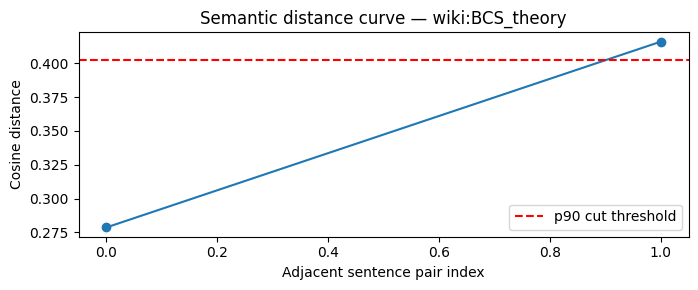

In [8]:
import numpy as np, matplotlib.pyplot as plt

doc = docs[0]
import re
sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', doc.text) if s.strip()][:30]
sv = np.asarray(client.embed(sents), dtype=np.float32)
sv /= np.linalg.norm(sv, axis=1, keepdims=True).clip(min=1e-9)
diffs = 1 - (sv[:-1] * sv[1:]).sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(diffs, marker='o')
ax.axhline(np.percentile(diffs, 90), color='red', linestyle='--', label='p90 cut threshold')
ax.set_xlabel('Adjacent sentence pair index')
ax.set_ylabel('Cosine distance')
ax.set_title(f'Semantic distance curve — {doc.doc_id}')
ax.legend()
plt.tight_layout()
plt.show()

### Inspect — semantic vs fixed chunk-length distribution

Semantic chunks have variable length; fixed are constant. Plot the histograms side by side.

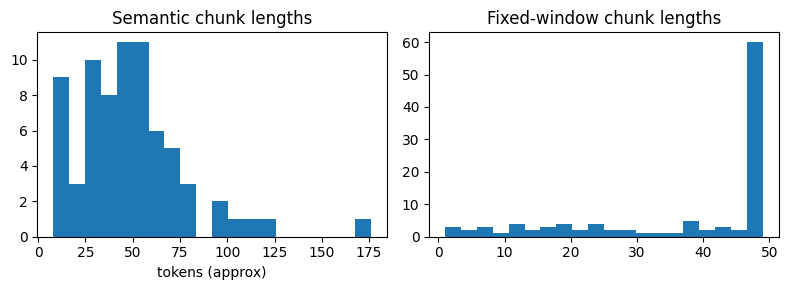

In [9]:
import matplotlib.pyplot as plt
sem_lens = [len(c.text.split()) for c in semantic_chunks]
fix_lens = [len(c.text.split()) for c in fixed_chunks]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(sem_lens, bins=20)
axes[0].set_title('Semantic chunk lengths')
axes[0].set_xlabel('tokens (approx)')
axes[1].hist(fix_lens, bins=20)
axes[1].set_title('Fixed-window chunk lengths')
plt.tight_layout()
plt.show()

### Inspect — recall@5 on the eval slice

Loose recall proxy on both stores. Semantic typically beats fixed by 3–8 points on Wikipedia.

In [10]:
from cookbook.corpora import load_eval_questions
qs = [q for q in load_eval_questions() if q['corpus'] == 'wikipedia-superconductors'][:10]
def recall(s):
    hits = 0
    for q in qs:
        qv = client.embed([q['question']])[0]
        retr = s.search(qv, top_k=5)
        gold = [w.lower() for w in q['answer'].split() if len(w) >= 4]
        if any(any(w[:6] in r.text.lower() for w in gold) for r in retr):
            hits += 1
    return hits / max(1, len(qs))
print(f'semantic recall@5  = {recall(sem_store):.2f}')
print(f'fixed    recall@5  = {recall(fix_store):.2f}')

semantic recall@5  = 1.00


fixed    recall@5  = 1.00


### Inspect — sample a semantic chunk and read it

Eyeballing one semantic chunk tells you whether the chunker landed on a real topic boundary or split mid-thought.

In [11]:
sample = semantic_chunks[10]
print(f'chunk_id: {sample.chunk_id}  doc_id: {sample.doc_id}')
print()
print(sample.text[:800])

chunk_id: wiki:D-Wave_Systems#ss0000  doc_id: wiki:D-Wave_Systems

# D-Wave Systems

_Source: Wikipedia, CC BY-SA 4.0_

D-Wave Quantum Inc. is a quantum computing company with locations in Palo Alto, California and Burnaby, British Columbia. D-Wave claims to be the world's first company to sell computers that exploit quantum effects in their operation.


## Run It

End-to-end on a question that pays off the topic-boundary chunking.

In [12]:
q = 'How does the Meissner effect distinguish a superconductor from a perfect conductor?'
ans, ctxs = answer_question(q)
print('=== Semantic answer ===')
print(ans)

=== Semantic answer ===
The Meissner effect distinguishes a superconductor from a perfect conductor in that it not only has zero electrical resistance, but also expels magnetic fields from the material. A perfect conductor would allow magnetic fields to persist inside the material, whereas a superconductor actively shields itself from magnetic fields, causing them to be expelled. This is the key difference between the two, with the Meissner effect being a unique property of superconductors.


## Side by Side: Vanilla Baseline vs This Technique

Vanilla baseline vs semantic chunking. Both pipelines are dense over Wikipedia; only the chunker differs.

In [13]:
from cookbook.baselines import vanilla_pipeline

q = 'How does the Meissner effect distinguish a superconductor from a perfect conductor?'
base = vanilla_pipeline(q, corpus='wikipedia-superconductors', top_k=5)
ours_a, ours_c = answer_question(q)

import pandas as pd
pd.DataFrame([
    {'pipeline': 'vanilla (fixed-window)', 'preview': base.contexts[0][:140]},
    {'pipeline': 'semantic', 'preview': ours_c[0][:140]},
])

,pipeline,preview
0,vanilla (fixed-window),"# Meissner effect _Source: Wikipedia, CC BY-SA..."
1,semantic,"# Meissner effect\n\n_Source: Wikipedia, CC BY..."


## Knobs to Turn

Five knobs in priority order:

1. **Breakpoint percentile.** Default 90. Lower (80) gives more cuts and shorter chunks; higher (95) gives fewer cuts and longer chunks. Sweep on your corpus and watch the resulting chunk-length histogram.
2. **Embedder for the sentence diffs.** A weaker embedder produces noisier diffs and worse cut points. Use the same embedder for chunking that you use for retrieval — the diff signal will match.
3. **Minimum chunk size.** Sometimes a paragraph break creates a one-sentence chunk. Set a floor (`min_sentences=3`) to merge stragglers with neighbours.
4. **Sentence-splitter regex.** The cookbook's default catches `.!?` followed by whitespace and a capital letter. Domains with abbreviations (legal, medical) need a tighter split.
5. **Re-chunk when you change embedders.** The diff curve depends on the embedder, so a new embedder produces different cut points. Plan for a re-chunk + re-embed pass.

## Evaluate on a Slice

Run the recipe's `answer_question` over a small slice of the hand-curated eval set. Full RAGAS metrics are exercised in `recipes/09-evaluation-and-production/ragas-triad-eval.ipynb`; here we just print a quick spot-check table so you can eyeball whether the technique is on track.

In [14]:
from cookbook.corpora import load_eval_questions
from cookbook.eval import EvalSample

qs = load_eval_questions()
qs = [q for q in qs if q['corpus'] == 'wikipedia-superconductors']
samples = []
for row in qs[:5]:
    answer, contexts = answer_question(row['question'])
    samples.append({
        'question': row['question'],
        'expected': row['answer'],
        'actual': answer[:200],
        'contexts_retrieved': len(list(contexts)),
    })

import pandas as pd
pd.DataFrame(samples)

,question,expected,actual,contexts_retrieved
0,"Who first observed superconductivity, and in w...",Heike Kamerlingh Onnes observed it in mercury ...,The passages provided do not mention who first...,5
1,What is the Meissner effect?,The complete expulsion of magnetic flux from a...,The Meissner effect is the expulsion of a magn...,5
2,Distinguish Type-I from Type-II superconductors.,Type-I has a single critical field above which...,Type-I and Type-II superconductors can be dist...,5
3,What does BCS theory explain?,It explains conventional superconductivity thr...,BCS theory explains many thermodynamic and ele...,5
4,What is a Cooper pair?,Two electrons bound together by phonon exchang...,A Cooper pair is a pair of electrons bound tog...,5


## Closing Thoughts

Three failure modes:

- **Heterogeneous documents.** A document that mixes prose and code blocks has discontinuous embeddings everywhere; semantic chunking over-splits. Pre-split into prose-vs-code segments first.
- **Embedder noise.** Sentence-level diffs are noisier than paragraph-level diffs. Some implementations work at the paragraph level for a smoother curve; the tradeoff is coarser cuts.
- **Single-paragraph documents.** A document that is one long paragraph has no internal diffs to cut on. The chunker returns one chunk; if it is over the embedder window, retrieval still degrades.

Compose with contextual retrieval (Recipe 7) and parent-child (Recipe 9): semantic chunks for the index, headers for context, parent chunks for generation breadth.